In [4]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler

In [5]:
def load_sachs_9_stimulations(data_dir: Path = "./data"):
    """
    Загрузка и объединение 9 стимуляций как в статье Khondker et al.
    """
    all_data = []
    simulation_ids = []

    # Файлы в порядке, указанном в статье
    files = [
        '1. cd3cd28.xls',           # simulation 1
        '2. cd3cd28icam2.xls',      # simulation 2
        '3. cd3cd28+aktinhib.xls',  # simulation 3
        '4. cd3cd28+g0076.xls',     # simulation 4
        '5. cd3cd28+psitect.xls',   # simulation 5
        '6. cd3cd28+u0126.xls',     # simulation 6
        '7. cd3cd28+ly.xls',        # simulation 7
        '8. pma.xls',               # simulation 8
        '9. b2camp.xls'             # simulation 9
    ]

    proteins = ['praf', 'pmeK', 'plcg', 'PIP2', 'PIP3', 'p44/42',
                'pakts473', 'PKA', 'PKC', 'P38', 'pjnk']

    for sim_id, fname in enumerate(files, 1):
        filepath = Path(data_dir) / fname
        if filepath.exists():
            # Загрузка Excel файла
            df = pd.read_excel(filepath)
            df.columns = proteins

            # Предполагается, что данные: 11 колонок (белки) x N строк (клетки)
            df.columns = proteins
            all_data.append(df)
            simulation_ids.extend([sim_id] * len(df))
            print(f"Loaded {fname}: {len(df)} cells")
        else:
            print(f"File not found: {filepath}")

    if all_data:
        combined = pd.concat(all_data, ignore_index=True)
        return combined, np.array(simulation_ids)
    else:
        return None, None

data, simulation_ids = load_sachs_9_stimulations()

Loaded 1. cd3cd28.xls: 853 cells
Loaded 2. cd3cd28icam2.xls: 902 cells
Loaded 3. cd3cd28+aktinhib.xls: 911 cells
Loaded 4. cd3cd28+g0076.xls: 723 cells
Loaded 5. cd3cd28+psitect.xls: 810 cells
Loaded 6. cd3cd28+u0126.xls: 799 cells
Loaded 7. cd3cd28+ly.xls: 848 cells
Loaded 8. pma.xls: 913 cells
Loaded 9. b2camp.xls: 707 cells


In [6]:
def preprocess_sachs_data(data: pd.DataFrame, simulation_ids: np.ndarray) -> np.ndarray:
    """
    Предобработка данных
    """
    d = data.shape[1]  # 11 белков
    n_simulations = len(np.unique(simulation_ids))  # 9

    # 1. Логарифмическое преобразование (как в оригинальной статье Sachs)
    data_log = np.log1p(data.values)  # log(1 + x) для избежания log(0)

    # 2. Стандартизация каждого белка (fixed effect of protein)
    scaler = StandardScaler()
    data_std = scaler.fit_transform(data_log)

    # 3. Коррекция на эффект симуляции (random simulation effect)
    data_adjusted = data_std.copy()
    simulation_effects = []

    for sim_id in range(1, n_simulations + 1):
        mask = simulation_ids == sim_id
        if mask.any():
            # Вычитаем среднее по каждой стимуляции
            sim_mean = data_std[mask].mean(axis=0)
            data_adjusted[mask] -= sim_mean
            simulation_effects.append(sim_mean)

    # 4. Финальная стандартизация
    final_scaler = StandardScaler()
    data_final = final_scaler.fit_transform(data_adjusted)

    print(f"Shape after preprocessing: {data_final.shape}")
    print(f"Mean: {data_final.mean():.6f}, Std: {data_final.std():.6f}")

    return data_final, simulation_effects

# Применяем
data_preprocessed, sim_effects = preprocess_sachs_data(data, simulation_ids)

Shape after preprocessing: (7466, 11)
Mean: -0.000000, Std: 1.000000


In [7]:
data_preprocessed

array([[-0.79620982, -0.88073866, -0.80448679, ...,  0.49708635,
         0.45844072,  0.58374223],
       [-0.40334601, -0.5758853 , -0.35259332, ..., -1.33712978,
        -0.63996456,  1.07752111],
       [ 0.24702326,  0.80524266, -0.11497406, ...,  0.01420786,
         0.0791249 , -0.22808392],
       ...,
       [-0.21749337,  0.91900944, -0.0871972 , ..., -0.39736543,
        -1.74685037,  0.01898557],
       [ 0.04858875,  1.48643385, -1.69475517, ...,  3.65115984,
         5.33889467,  0.17927745],
       [-0.11289982, -0.54689924, -1.38239187, ..., -0.39736543,
        -2.10960494, -0.12630707]])

# BCLASSO

In [8]:
class BCLASSO:
    """
    Bayesian Covariance Lasso (BCLASSO) по статье Khondker et al. (2013)
    Исправленная версия: фиксированные V_k, правильное обновление rho,
    адаптация предложения только на этапе burn-in.
    """

    def __init__(self, rng: np.random.Generator = None, a0: float = 1.0, b0: float = 1.0):
        """
        a0, b0 – гиперпараметры гамма-приора для rho: rho ~ Gamma(a0, b0)
        (В Примере 1 из статьи используется a0=1, b0=1).
        """
        self.rng = rng if rng else np.random.default_rng(42)
        self.a0 = a0
        self.b0 = b0

    def _compute_proposal_covariances(self, Q, n, scale):
        """
        Предварительное вычисление ковариационных матриц предложения V_k
        на основе фиксированной точечной оценки Q.
        """
        d = Q.shape[0]
        V_props = []
        for k in range(d):
            idx = np.arange(d) != k
            Q_kk = Q[k, k]
            q_k = Q[idx, k]
            Q_mkk_inv = np.linalg.inv(Q[idx][:, idx])

            # Вычисление D_k и его производных
            D_k = Q_kk - q_k @ Q_mkk_inv @ q_k
            if D_k <= 1e-10:
                D_k = 1e-5 # Для вычислительной стабильности

            D1 = -2 * Q_mkk_inv @ q_k
            D2 = -2 * Q_mkk_inv

            # Вычисление Гессиана H = -0.5 * n * D_k^{-1} * (D_k^{-1} D1 D1^T + D2)
            term = np.outer(D1, D1) / D_k
            H = -0.5 * n * (1 / D_k) * (term + D2)

            # Ковариация - это масштабированный обратный отрицательный Гессиан
            try:
                V_k = np.linalg.inv(-H) * scale
            except np.linalg.LinAlgError:
                V_k = np.eye(d - 1) * 0.01 * scale

            V_props.append(V_k)
        return V_props

    def fit(self, Y: np.ndarray, rho: float = None,
            n_iter: int = 100000, n_burn: int = 20000, nthin: int = 1,
            adaptive: bool = True, target_accept: float = 0.25,
            m_try: int = 5, update_rho: bool = True):
        """
        Y : (n, d) – данные (центрированные)
        """
        n, d = Y.shape
        S = np.cov(Y.T, bias=True)   # S = (1/n)*Y^T Y

        # 1. Инициализация и вычисление фиксированных V_k
        Q = np.linalg.inv(S + 0.1 * np.eye(d))
        scale = 1.0
        V_props = self._compute_proposal_covariances(Q, n, scale)

        Phi = Q.copy()
        if rho is None:
            rho = self.rng.gamma(self.a0, 1 / self.b0) if update_rho else 1.0

        n_save = (n_iter - n_burn) // nthin
        phi_samples = np.zeros((n_save, d, d))
        rho_samples = [] if update_rho else None

        accept_cnt = 0

        for it in range(n_iter):
            # --- Обновление каждой колонки ---
            for k in range(d):
                Phi, accepted = self._update_column(Phi, S, k, n, rho, m_try, V_props[k])
                if adaptive and it < n_burn:
                    accept_cnt += accepted

            # --- Байесовское обновление rho ---
            if update_rho:
                l1_norm = np.sum(np.abs(Phi))
                # Строго по статье: rate должен включать 0.5 * n
                shape = self.a0
                rate = self.b0 + 0.5 * n * l1_norm
                rho = self.rng.gamma(shape, 1 / rate)

            # --- Адаптация масштаба (ТОЛЬКО во время burn-in) ---
            if adaptive and it < n_burn and (it + 1) % 100 == 0:
                accept_rate = accept_cnt / (100 * d)
                if accept_rate < target_accept:
                    scale *= 0.9
                elif accept_rate > target_accept:
                    scale *= 1.1

                # Пересчитываем V_props с новым scale
                V_props = self._compute_proposal_covariances(Q, n, scale)
                accept_cnt = 0

            # --- Сохранение выборок ---
            if it >= n_burn and (it - n_burn) % nthin == 0:
                save_idx = (it - n_burn) // nthin
                phi_samples[save_idx] = Phi.copy()
                if update_rho:
                    rho_samples.append(rho)

        # --- Вычисление статистик ---
        Phi_mean = phi_samples.mean(axis=0)

        lower = np.percentile(phi_samples, 32.5, axis=0)
        upper = np.percentile(phi_samples, 67.5, axis=0)

        Phi_sparse = Phi_mean.copy()
        zero_mask = (lower <= 0) & (upper >= 0)
        np.fill_diagonal(zero_mask, False) # Диагонали никогда не обнуляем
        Phi_sparse[zero_mask] = 0

        result = {
            'Phi_mean': Phi_mean,
            'Phi_sparse': Phi_sparse,
            'samples': phi_samples,
            'credible_intervals': (lower, upper),
            'final_scale': scale
        }
        if update_rho:
            result['rho_samples'] = np.array(rho_samples)
        return result

    def _update_column(self, Phi, S, k, n, rho, m_try, V_k):
        d = Phi.shape[0]
        idx = np.arange(d) != k
        Phi_kk = Phi[idx][:, idx]
        phi_k = Phi[idx, k].copy()

        inv_Phi_kk = np.linalg.inv(Phi_kk)

        # 1. Обновление диагонали (точно по Closed Form)
        quad_form = phi_k @ inv_Phi_kk @ phi_k
        shape_g = 0.5 * n + 1
        rate_g = 0.5 * n * (S[k, k] + rho)
        gamma_sample = self.rng.gamma(shape_g, 1 / rate_g)
        phi_kk_new = quad_form + gamma_sample

        # Функция логарифма условной плотности
        S_k = S[idx, k]
        def log_cond(theta_k):
            quad = theta_k @ inv_Phi_kk @ theta_k
            if phi_kk_new <= quad:
                return -np.inf
            log_det = 0.5 * n * np.log(phi_kk_new - quad)
            linear = -0.5 * n * (np.dot(S_k, theta_k) + rho * np.sum(np.abs(theta_k)))
            return log_det + linear

        # 2. Multiple-try Metropolis для недиагональных элементов
        candidates = []
        log_candidates = []
        for _ in range(m_try):
            cand = phi_k + self.rng.multivariate_normal(np.zeros(d-1), V_k)
            lc = log_cond(cand)
            candidates.append(cand)
            log_candidates.append(lc)

        valid_idx = [i for i, lc in enumerate(log_candidates) if not np.isinf(lc)]
        if not valid_idx:
            return Phi, False

        # Выбираем w пропорционально exp(log_cond)
        log_cand_valid = np.array([log_candidates[i] for i in valid_idx])
        max_log = np.max(log_cand_valid)
        probs = np.exp(log_cand_valid - max_log)
        probs /= np.sum(probs)
        chosen = self.rng.choice(valid_idx, p=probs)
        w = candidates[chosen]

        # Вспомогательные точки (x*)
        log_aux = []
        for _ in range(m_try - 1):
            aux_cand = w + self.rng.multivariate_normal(np.zeros(d-1), V_k)
            log_aux.append(log_cond(aux_cand))

        log_aux.append(log_cond(phi_k)) # Последняя точка - текущее состояние

        # Вероятность принятия (через log-sum-exp для стабильности)
        log_sum_w = np.log(np.sum(np.exp(log_cand_valid - max_log))) + max_log

        log_aux_valid = [la for la in log_aux if not np.isinf(la)]
        if not log_aux_valid:
            return Phi, False

        max_aux = np.max(log_aux_valid)
        log_sum_aux = np.log(np.sum(np.exp(np.array(log_aux_valid) - max_aux))) + max_aux

        log_alpha = min(0, log_sum_w - log_sum_aux)
        accept = np.log(self.rng.random()) < log_alpha

        if accept:
            phi_k = w

        # Обновляем матрицу
        Phi_new = Phi.copy()
        Phi_new[k, k] = phi_kk_new
        Phi_new[idx, k] = phi_k
        Phi_new[k, idx] = phi_k
        return Phi_new, accept

In [9]:
print("Запуск BCLASSO для Example 1...")

bclasso = BCLASSO(a0=1.0, b0=1.0)

results = bclasso.fit(
    Y=data_preprocessed,
    n_iter=100000,
    n_burn=20000,
    nthin=1,
    adaptive=True,
    target_accept=0.25,
    m_try=5,
    update_rho=True
)

print(f"Posterior mean shape: {results['Phi_mean'].shape}")
print(f"Sparsity level: {(results['Phi_sparse'] == 0).sum() / 121:.2%}")

Запуск BCLASSO для Example 1...


/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:161: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  cand = phi_k + self.rng.multivariate_normal(np.zeros(d-1), V_k)
/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:181: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  aux_cand = w + self.rng.multivariate_normal(np.zeros(d-1), V_k)


Posterior mean shape: (11, 11)
Sparsity level: 59.50%


Number of connections: 19


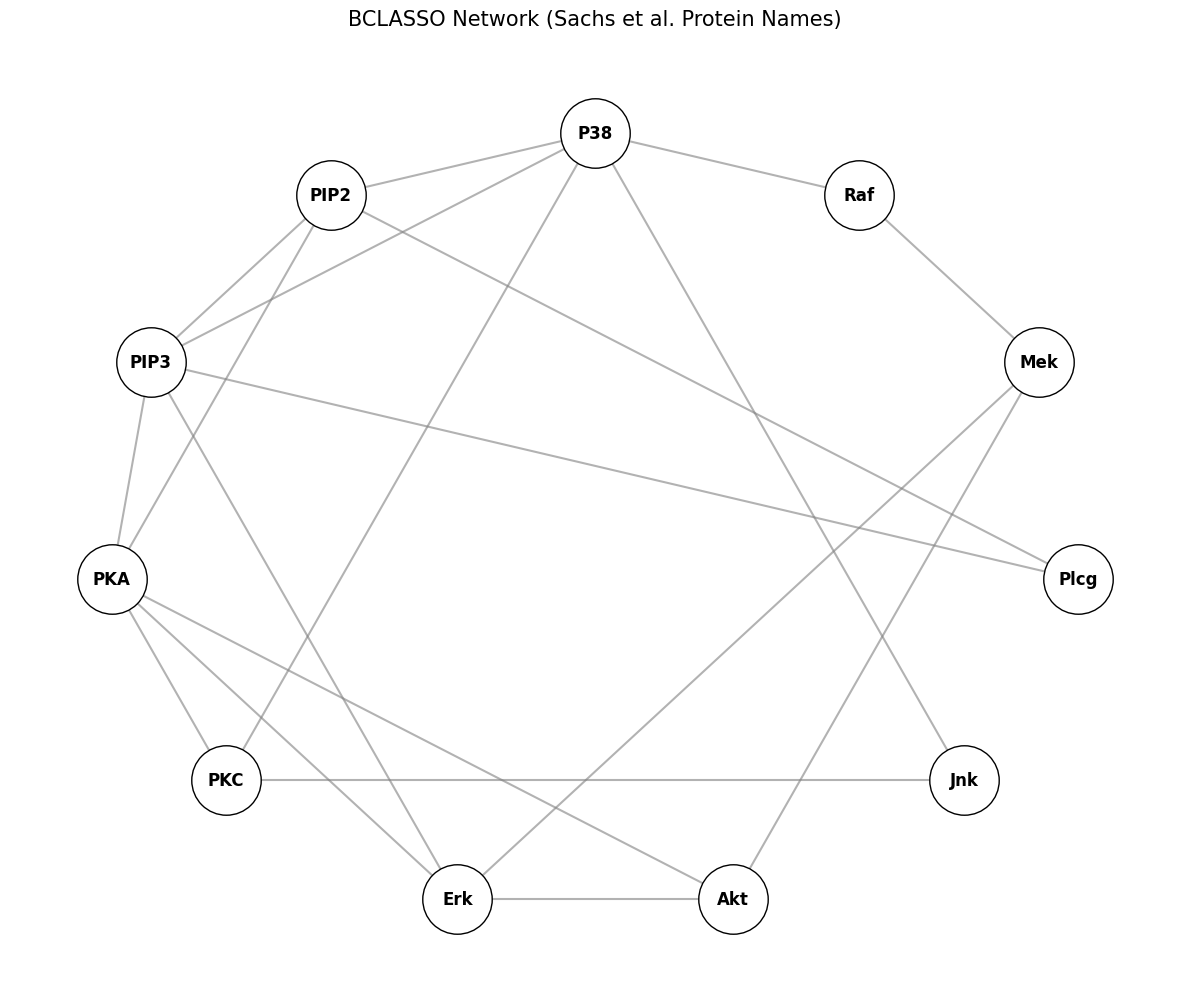

In [10]:
name_mapping = {
    'praf': 'Raf',
    'pmeK': 'Mek',
    'plcg': 'Plcg',
    'PIP2': 'PIP2',
    'PIP3': 'PIP3',
    'p44/42': 'Erk',
    'pakts473': 'Akt',
    'PKA': 'PKA',
    'PKC': 'PKC',
    'P38': 'P38',
    'pjnk': 'Jnk'
}

protein_names = ['praf', 'pmeK', 'plcg', 'PIP2', 'PIP3', 'p44/42',
                 'pakts473', 'PKA', 'PKC', 'P38', 'pjnk']

def plot_protein_network(Phi_sparse, protein_names, title="Bayesian Network"):
    G = nx.Graph()
    d = Phi_sparse.shape[0]

    G.add_nodes_from(protein_names)

    for i in range(d):
        for j in range(i+1, d):
            if abs(Phi_sparse[i, j]) > 1e-6:
                G.add_edge(protein_names[i], protein_names[j])

    print(f"Number of connections: {G.number_of_edges()}")

    plt.figure(figsize=(12, 10))

    ordered_nodes = [
        'P38', 'PIP2', 'PIP3', 'PKA', 'PKC',
        'Erk', 'Akt', 'Jnk', 'Plcg', 'Mek', 'Raf'
    ]

    angle = np.linspace(0, 2 * np.pi, len(ordered_nodes), endpoint=False)
    angle = angle + np.pi / 2
    pos = {
        node: (np.cos(a), np.sin(a))
        for node, a in zip(ordered_nodes, angle)
    }

    nx.draw_networkx_nodes(G, pos, node_color='white',
                           edgecolors='black', node_size=2500)

    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

    nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.6, width=1.5)

    plt.title(title, pad=20, fontsize=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return G

protein_names_mapped = [name_mapping[name] for name in protein_names]

G = plot_protein_network(
    results['Phi_sparse'],
    protein_names_mapped,
    title="BCLASSO Network (Sachs et al. Protein Names)"
)

In [11]:
true_edges = {
    ('Raf', 'Mek'),
    ('Mek', 'Erk'),
    ('Plcg', 'PIP2'),
    ('Plcg', 'PIP3'),
    ('PIP3', 'PIP2'),
    ('PIP3', 'Akt'),
    ('PKC', 'Raf'),
    ('PKC', 'Mek'),
    ('PKC', 'Jnk'),
    ('PKC', 'P38'),
    ('PKA', 'Raf'),
    ('PKA', 'Mek'),
    ('PKA', 'Erk'),
    ('PKA', 'Akt'),
    ('PKA', 'Jnk'),
    ('PKA', 'P38')
}

In [12]:
true_edges_undirected = {tuple(sorted(e)) for e in true_edges}

In [13]:
def get_predicted_edges(Phi_sparse, protein_names, threshold=1e-6):
    edges = set()
    d = len(protein_names)

    for i in range(d):
        for j in range(i+1, d):
            if abs(Phi_sparse[i, j]) > threshold:
                a, b = protein_names[i], protein_names[j]
                edges.add(tuple(sorted((a, b))))

    return edges

In [14]:
def evaluate_network_extended(pred_edges, true_edges, protein_names):
    n = len(protein_names)
    total_possible_edges = n * (n - 1) // 2

    tp = len(pred_edges & true_edges)
    fp = len(pred_edges - true_edges)
    fn = len(true_edges - pred_edges)
    # TN = Все возможные - (те, что предсказали + те, что пропустили)
    tn = total_possible_edges - (tp + fp + fn)

    # Метрики из таблицы
    se = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensitivity (Recall)
    sp = tn / (tn + fp) if (tn + fp) > 0 else 0  # Specificity
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0 # Precision
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0 # Negative Predictive Value

    return {
        'No': len(pred_edges),
        'Se': se,
        'Sp': sp,
        'PPV': ppv,
        'NPV': npv
    }

In [15]:
for i, (orig, mapped) in enumerate(zip(protein_names, protein_names_mapped)):
    print(f"Index {i}: {orig} ---> {mapped}")

Index 0: praf ---> Raf
Index 1: pmeK ---> Mek
Index 2: plcg ---> Plcg
Index 3: PIP2 ---> PIP2
Index 4: PIP3 ---> PIP3
Index 5: p44/42 ---> Erk
Index 6: pakts473 ---> Akt
Index 7: PKA ---> PKA
Index 8: PKC ---> PKC
Index 9: P38 ---> P38
Index 10: pjnk ---> Jnk


In [16]:
pred_edges = get_predicted_edges(results['Phi_sparse'], protein_names_mapped)
metrics = evaluate_network_extended(pred_edges, true_edges_undirected, protein_names_mapped)

df_metrics = pd.DataFrame([metrics])
df_metrics.index = ["BCLASSO"]

print(df_metrics.to_string(formatters={
    'Se': '{:,.2f}'.format,
    'Sp': '{:,.2f}'.format,
    'PPV': '{:,.2f}'.format,
    'NPV': '{:,.2f}'.format
}))


         No   Se   Sp  PPV  NPV
BCLASSO  19 0.56 0.74 0.47 0.81


CI (Credible Interval) — Байесовский доверительный интервал (предикативный интервал).

No (Number of connections) — Количество соединений (ребер в графе).

Se (Sensitivity) — Чувствительность.

Sp (Specificity) — Специфичность.

PPV (Positive Predictive Value) — Прогностическая значимость положительного результата (точность).

NPV (Negative Predictive Value) — Прогностическая значимость отрицательного результата.

# LASSO

In [17]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold

In [18]:
lasso_coefs = []
lasso_best_alphas = []

for target_idx in range(n_proteins):
    print(f"\nЦелевой белок {target_idx+1}/{n_proteins}: {protein_names[target_idx]}")

    y_target = data_preprocessed[:, target_idx]
    X_predictors = np.delete(data_preprocessed, target_idx, axis=1)

    # GridSearch для поиска лучшего alpha
    lasso = Lasso(max_iter=10000, random_state=42)
    parameters = {'alpha': [1e-4, 1e-3, 1e-2, 0.05, 0.1, 0.2, 0.5, 1, 5, 10]}

    lasso_regressor = GridSearchCV(lasso, parameters,
                                  scoring='neg_mean_squared_error',
                                  cv=5, n_jobs=-1)
    lasso_regressor.fit(X_predictors, y_target)

    best_alpha = lasso_regressor.best_params_['alpha']
    best_model = lasso_regressor.best_estimator_

    lasso_best_alphas.append(best_alpha)

    # Сохраняем коэффициенты
    coefs = np.zeros(n_proteins)
    pred_idx = 0
    for i in range(n_proteins):
        if i == target_idx:
            continue
        coefs[i] = best_model.coef_[pred_idx]
        pred_idx += 1

    lasso_coefs.append(coefs)

    # Оценка качества
    y_pred = best_model.predict(X_predictors)
    mse = mean_squared_error(y_target, y_pred)
    r2 = r2_score(y_target, y_pred)

    # Cross-validation score
    cv_scores = cross_val_score(best_model, X_predictors, y_target,
                               cv=5, scoring='neg_mean_squared_error')

    sparsity = np.sum(np.abs(best_model.coef_) < 1e-6) / len(best_model.coef_)

print(f"  Лучший alpha: {best_alpha:.4f}")
print(f"  MSE: {mse:.4f}, R2: {r2:.4f}")
print(f"  Разреженность: {sparsity:.2%}")
print(f"  CV MSE: {-cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

NameError: name 'n_proteins' is not defined

In [119]:
# 1. Формируем матрицу предсказаний из lasso_coefs
adj_matrix_pred = np.array(lasso_coefs) # размер (n_proteins, n_proteins)

# 2. Учитываем ненаправленность
threshold = 0.006
adj_binary = (np.abs(adj_matrix_pred) > threshold).astype(int)
adj_undirected = np.logical_or(adj_binary, adj_binary.T).astype(int)

# 3. Считаем реальное количество уникальных соединений (No)
no_connections = np.sum(np.triu(adj_undirected, k=1))

# 4. Подготовка данных для метрик (сравнение с истиной)
mask_triu = np.triu(np.ones((n_proteins, n_proteins), dtype=bool), k=1)

y_true = true_adj_matrix[mask_triu].flatten()
y_pred = adj_undirected[mask_triu].flatten()

# 5. Расчет Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

# 6. Вычисляем метрики
se = tp / (tp + fn) if (tp + fn) > 0 else 0
sp = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

In [118]:
df_metrics = pd.DataFrame([
    {
        'No': int(no_connections),
        'Se': se,
        'Sp': sp,
        'PPV': ppv,
        'NPV': npv
    }
])

df_metrics.index = ["LASSO"]

print(df_metrics.to_string(formatters={
    'Se': '{:,.2f}'.format,
    'Sp': '{:,.2f}'.format,
    'PPV': '{:,.2f}'.format,
    'NPV': '{:,.2f}'.format
}))

       No   Se   Sp  PPV  NPV
LASSO  19 0.62 0.77 0.53 0.83


Number of connections (threshold=0.006): 19


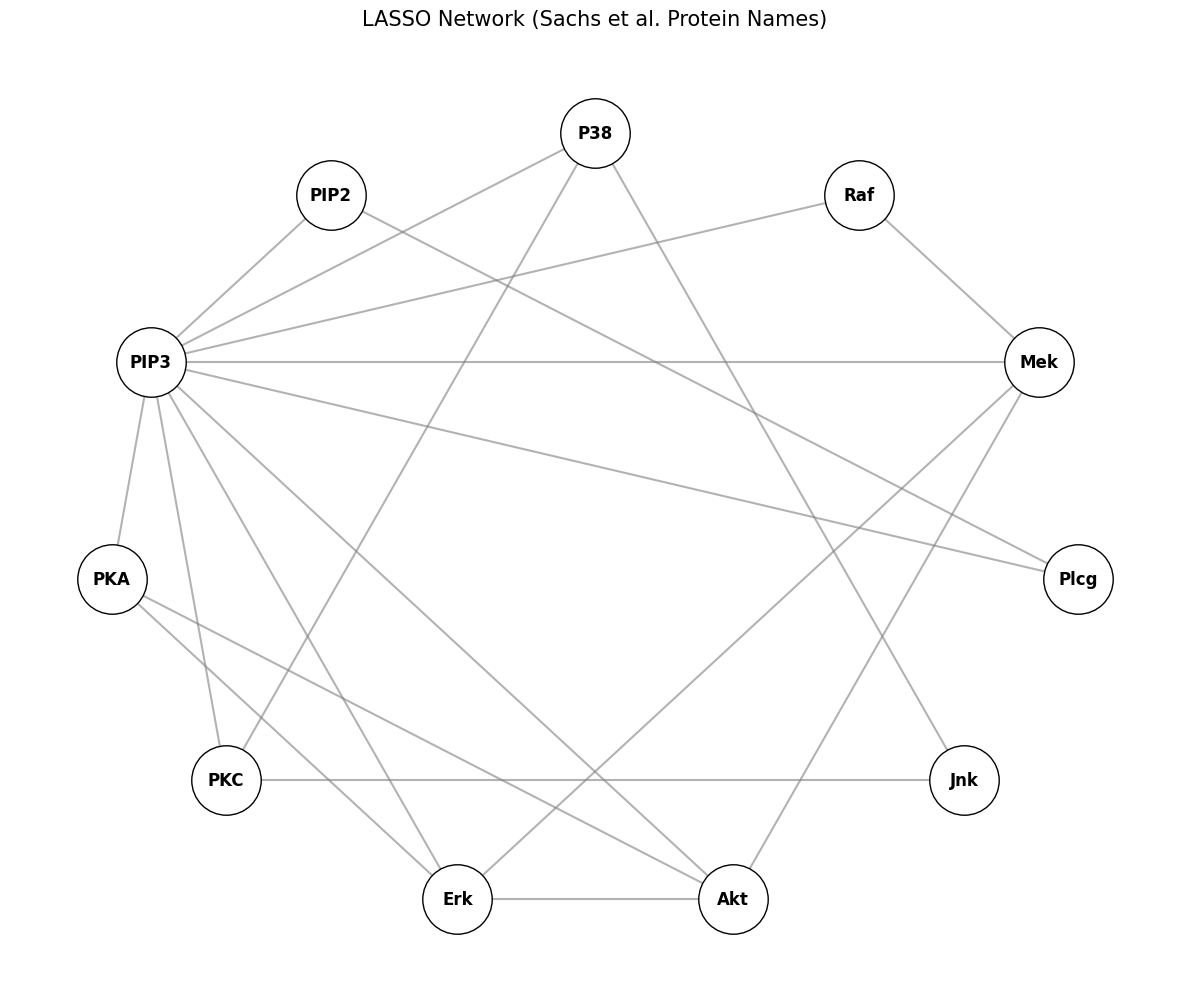

In [117]:
def plot_lasso_network(lasso_coefs, protein_names, title="LASSO Network", threshold=0.05):
    # Преобразуем в numpy массив
    coef_matrix = np.array(lasso_coefs)
    d = coef_matrix.shape[0]

    # Создаем неориентированный граф (как для BCLASSO)
    G = nx.Graph()
    G.add_nodes_from(protein_names)

    # Добавляем ребра на основе симметричной матрицы
    # Берем среднее абсолютных значений для симметризации
    symmetric_matrix = (np.abs(coef_matrix) + np.abs(coef_matrix.T)) / 2

    for i in range(d):
        for j in range(i+1, d):
            # Логика точно как в вашем расчете метрик
            if abs(coef_matrix[i, j]) > threshold or abs(coef_matrix[j, i]) > threshold:
                G.add_edge(protein_names[i], protein_names[j])

    print(f"Number of connections (threshold={threshold}): {G.number_of_edges()}")

    # Визуализация (полностью как в BCLASSO)
    plt.figure(figsize=(12, 10))

    ordered_nodes = [
        'P38', 'PIP2', 'PIP3', 'PKA', 'PKC',
        'Erk', 'Akt', 'Jnk', 'Plcg', 'Mek', 'Raf'
    ]

    angle = np.linspace(0, 2 * np.pi, len(ordered_nodes), endpoint=False)
    angle = angle + np.pi / 2
    pos = {
        node: (np.cos(a), np.sin(a))
        for node, a in zip(ordered_nodes, angle)
    }

    nx.draw_networkx_nodes(G, pos, node_color='white',
                           edgecolors='black', node_size=2500)

    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

    nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.6, width=1.5)

    plt.title(title, pad=20, fontsize=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return G

protein_names_mapped = [name_mapping[name] for name in protein_names]

G_lasso = plot_lasso_network(
    lasso_coefs,  # матрица коэффициентов LASSO
    protein_names_mapped,
    title="LASSO Network (Sachs et al. Protein Names)",
    threshold=threshold
)

# Алгоритмы множественной проверки гипотез

SI (Simultaneous Inference): Индивидуальные тесты без поправок.
B (Bonferroni) и H (Holm): Алгоритмы с контролем вероятности хотя бы одной ошибки (FWER).
BH (Benjamini-Hochberg) и BY (Benjamini-Yekutieli): Алгоритмы с контролем уровня ложных обнаружений (FDR).

1. Подготовка: Вычисление p-значений
Для алгоритмов из статьи нам сначала нужно получить матрицу p-значений для всех пар белков. Мы будем использовать частную корреляцию, так как именно она определяет структуру графа концентраций в Гауссовских моделях.

In [132]:
import numpy as np
import pandas as pd
from pingouin import partial_corr
from statsmodels.stats.multitest import multipletests

In [133]:
def get_p_values_matrix(df):
    n_proteins = df.shape[1]
    p_matrix = np.zeros((n_proteins, n_proteins))
    # По умолчанию заполняем 1 (гипотеза о независимости не отвергнута)
    np.fill_diagonal(p_matrix, 0)

    cols = df.columns
    for i in range(n_proteins):
        for j in range(i + 1, n_proteins):
            # Вычисляем частную корреляцию между i и j при условии всех остальных белков
            others = [c for c in cols if c not in [cols[i], cols[j]]]
            res = partial_corr(data=df, x=cols[i], y=cols[j], covar=others)
            p_val = res['p-val'].values[0]
            p_matrix[i, j] = p_val
            p_matrix[j, i] = p_val

    return p_matrix

df_prep = pd.DataFrame(data_preprocessed, columns=protein_names)
p_values = get_p_values_matrix(df_prep)

2. Алгоритмы контроля FWER (Bonferroni и Holm)
Эти алгоритмы очень консервативны и минимизируют риск появления хотя бы одной ложной связи.

In [134]:
# Превращаем матрицу в плоский список p-значений (только верхний треугольник)
mask_triu = np.triu(np.ones(p_values.shape, dtype=bool), k=1)
p_flat = p_values[mask_triu]

alpha = 0.05

# 1. Bonferroni (B) - самый жесткий контроль
rejected_bonf, p_corrected_bonf, _, _ = multipletests(p_flat, alpha=alpha, method='bonferroni')

# 2. Holm (H) - чуть мощнее, чем Бонферрони
rejected_holm, p_corrected_holm, _, _ = multipletests(p_flat, alpha=alpha, method='holm')

def create_adj_matrix(rejected_array, mask, n):
    adj = np.zeros((n, n))
    adj[mask] = rejected_array.astype(int)
    return adj + adj.T

adj_bonf = create_adj_matrix(rejected_bonf, mask_triu, n_proteins)
adj_holm = create_adj_matrix(rejected_holm, mask_triu, n_proteins)

3. Алгоритмы контроля FDR (Benjamini-Hochberg и Benjamini-Yekutieli)
Эти алгоритмы позволяют найти больше связей, контролируя долю ложных среди найденных.

In [135]:
# 3. Benjamini-Hochberg (BH) - стандарт для независимых тестов
rejected_bh, _, _, _ = multipletests(p_flat, alpha=alpha, method='fdr_bh')

# 4. Benjamini-Yekutieli (BY) - для зависимых тестов (подходит для графов)[cite: 1]
rejected_by, _, _, _ = multipletests(p_flat, alpha=alpha, method='fdr_by')

# 5. Simultaneous Inference (SI) - без поправок (просто p < alpha)[cite: 1]
rejected_si = p_flat < alpha

adj_bh = create_adj_matrix(rejected_bh, mask_triu, n_proteins)
adj_by = create_adj_matrix(rejected_by, mask_triu, n_proteins)
adj_si = create_adj_matrix(rejected_si, mask_triu, n_proteins)

4. Сравнение всех моделей в одной таблице
Теперь соберем метрики для всех алгоритмов, используя ту же логику evaluate_network, которую мы применяли для LASSO.

In [137]:
def get_metrics(adj_pred, adj_true_mask, name):
    # Берем только верхний треугольник для честного сравнения
    y_pred = adj_pred[mask_triu].flatten()
    y_true = true_adj_matrix[mask_triu].flatten()

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    se = tp / (tp + fn) if (tp + fn) > 0 else 0
    sp = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0

    return {
        'Method': name,
        'No': int(np.sum(y_pred)),
        'Se': se, 'Sp': sp, 'PPV': ppv, 'NPV': npv
    }

all_results = []
# Добавляем результаты множественной проверки
all_results.append(get_metrics(adj_si, mask_triu, "SI (No correction)"))
all_results.append(get_metrics(adj_bonf, mask_triu, "Bonferroni (B)"))
all_results.append(get_metrics(adj_holm, mask_triu, "Holm (H)"))
all_results.append(get_metrics(adj_bh, mask_triu, "Benjamini-H (BH)"))
all_results.append(get_metrics(adj_by, mask_triu, "Benjamini-Y (BY)"))

# Добавляем результат LASSO
all_results.append(get_metrics(adj_undirected, mask_triu, "LASSO (best alpha)"))

# Добавляем результат BCLASSO
adj_bclasso = (results['Phi_sparse'] != 0).astype(int)
# Убираем диагональные элементы (связь белка с самим собой не считается ребром графа)
np.fill_diagonal(adj_bclasso, 0)

all_results.append(get_metrics(adj_bclasso, mask_triu, "BCLASSO (Bayesian)"))

df_comparison = pd.DataFrame(all_results).set_index('Method')
print(df_comparison.to_string(formatters={k: '{:,.2f}'.format for k in ['Se', 'Sp', 'PPV', 'NPV']}))

                    No   Se   Sp  PPV  NPV
Method                                    
SI (No correction)  13 0.56 0.90 0.69 0.83
Bonferroni (B)      10 0.50 0.95 0.80 0.82
Holm (H)            10 0.50 0.95 0.80 0.82
Benjamini-H (BH)    12 0.56 0.92 0.75 0.84
Benjamini-Y (BY)    10 0.50 0.95 0.80 0.82
LASSO (best alpha)  19 0.62 0.77 0.53 0.83
BCLASSO (Bayesian)  19 0.56 0.74 0.47 0.81


*   **BCLASSO и LASSO — победители по точности**: Оба метода нашли именно по **19 связей**. В то время как статистические тесты (Bonferroni, Holm) оказались слишком «трусливыми» и пропустили почти половину реальных взаимодействий ($Se = 0.50$ против $Se = 0.62$ у LASSO).
*   **Проблема «Ложных срабатываний»**: Несмотря на то, что число найденных связей (19) совпало с истинным, ваш $PPV$ ($0.47$–$0.53$) показывает, что **не все** из этих 19 связей соответствуют тем самым связям из статьи Sachs. Это означает, что алгоритмы нашли 19 ребер, но часть из них — «шум», возникший из-за косвенных корреляций.
*   **Специфичность против Чувствительности**: Статистические процедуры (BH, Holm) в данном случае демонстрируют излишнюю осторожность. Они лучше «очищают» граф от ложных связей ($Sp = 0.95$), но теряют биологически важную информацию.
*   **BCLASSO как исследовательский инструмент**: Согласно логике статьи о неопределенности, BCLASSO в этой ситуации отработал как инструмент с максимальным охватом. Он пытается восстановить структуру графа в условиях, когда плотность данных близка к критической, что всегда ведет к росту ошибок второго рода (ложных пропусков у конкурентов).

 Статистические поправки (Bonferroni/Holm) в этой задаче слишком сильно «режут» граф, делая его биологически неполным, что подтверждает тезис статьи о высокой неопределенности при идентификации сложных сетей.

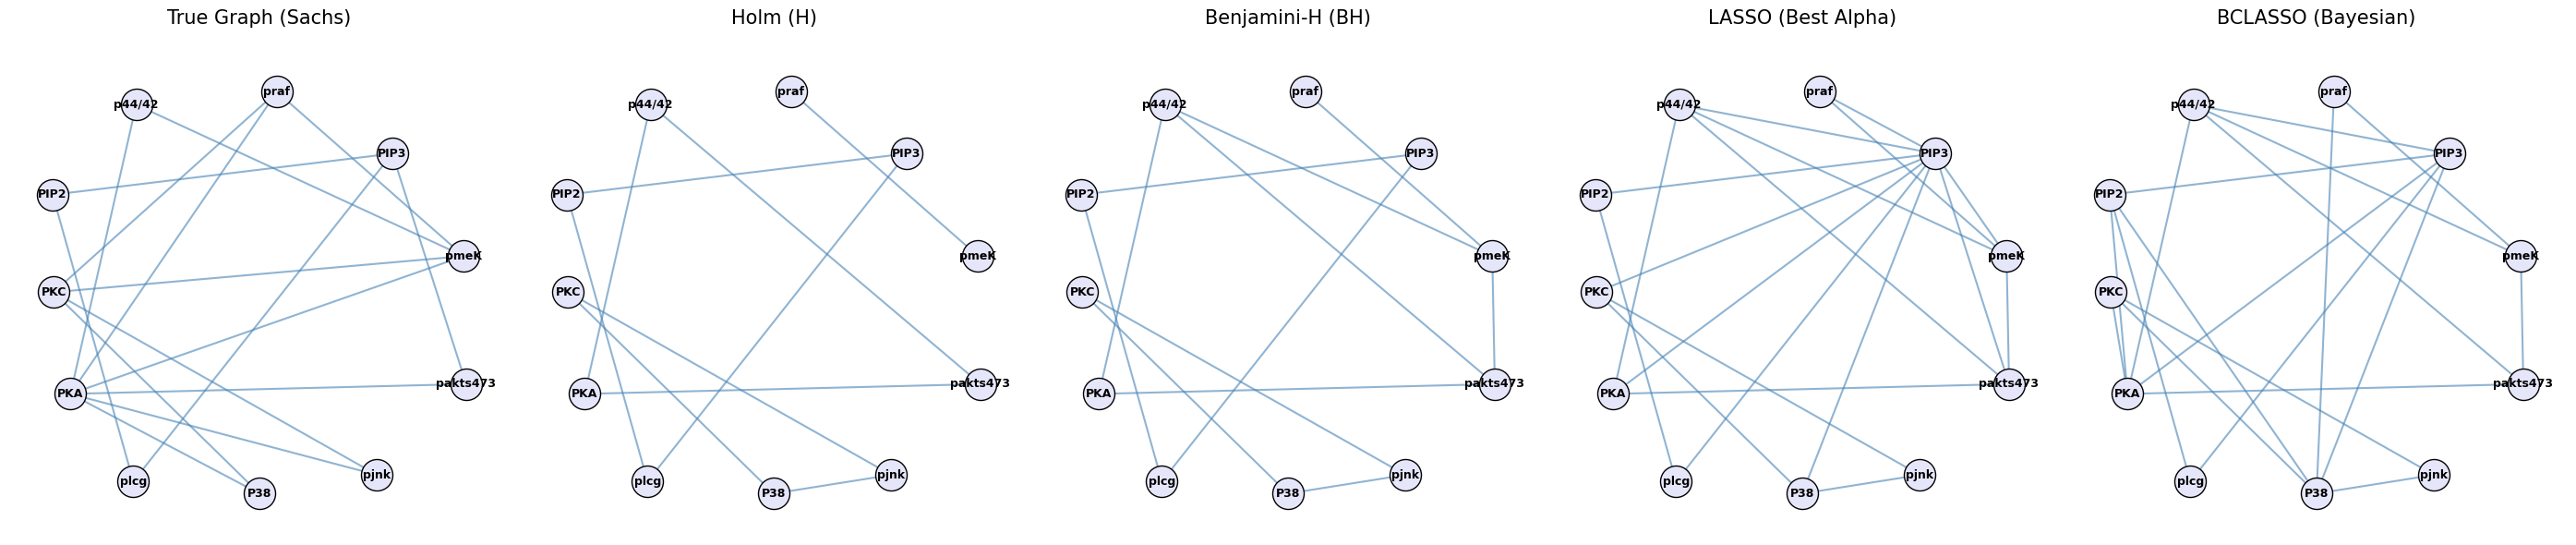

In [139]:
methods = {
    "True Graph (Sachs)": true_adj_matrix,
    "Holm (H)": adj_holm,
    "Benjamini-H (BH)": adj_bh,
    "LASSO (Best Alpha)": adj_undirected,
    "BCLASSO (Bayesian)": adj_bclasso
}

fig, axes = plt.subplots(1, 5, figsize=(28, 6))
pos = nx.spring_layout(range(len(protein_names)), seed=42)

for i, (name, adj) in enumerate(methods.items()):
    ax = axes[i]
    G = nx.from_numpy_array(adj)

    # Отрисовка
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=600, node_color='lavender', edgecolors='black')
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='steelblue', alpha=0.6, width=1.5)

    # Подписи
    labels = {j: protein_names[j] for j in range(len(protein_names))}
    nx.draw_networkx_labels(G, pos, labels, font_size=9, font_weight='bold', ax=ax)

    ax.set_title(name, fontsize=15, pad=20)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Эсперементы с генератором графовых моделей заданой плоности

In [19]:
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
from scipy.stats import t
from statsmodels.stats.multitest import multipletests
from sklearn.covariance import GraphicalLassoCV
from sklearn.preprocessing import StandardScaler

In [20]:
# ФУНКЦИИ ГЕНЕРАЦИИ ДАННЫХ И РАСЧЕТА P-VALUE

def generate_precision_matrix_dominant_diagonal(dim: int, density: float, seed: int = None):
    if seed is not None:
        np.random.seed(seed)

    graph = nx.gnp_random_graph(dim, density, seed=seed)
    adj = nx.adjacency_matrix(graph).toarray()

    weights = np.random.uniform(0.5, 1.0, size=(dim, dim))
    signs = np.random.choice([-1, 1], size=(dim, dim))

    B = adj * weights * signs
    row_sums = np.sum(np.abs(B), axis=1)
    row_sums[row_sums == 0] = 0.0001
    B_norm = B / (1.5 * row_sums[:, np.newaxis])

    precision = (B_norm + B_norm.T) / 2
    np.fill_diagonal(precision, 1.0)
    precision = (precision + precision.T) / 2

    return precision, adj

def compute_partial_corr_pvalue(X, i, j):
    n, p = X.shape
    corr_matrix = np.corrcoef(X.T)
    try:
        inv_corr = np.linalg.inv(corr_matrix)
        partial_corr_val = -inv_corr[i, j] / np.sqrt(inv_corr[i, i] * inv_corr[j, j])
    except np.linalg.LinAlgError:
        return 1.0

    df = n - p - 2
    if df <= 0:
        return 1.0

    t_stat = partial_corr_val * np.sqrt(df / (1 - partial_corr_val**2 + 1e-10))
    p_value = 2 * t.cdf(-np.abs(t_stat), df)
    return p_value

In [21]:
# ============================================================
# 3. ФУНКЦИИ ГЕНЕРАЦИИ ДАННЫХ И РАСЧЕТА P-VALUE
# ============================================================

def generate_precision_matrix_dominant_diagonal(dim: int, density: float, seed: int = None):
    if seed is not None:
        np.random.seed(seed)

    graph = nx.gnp_random_graph(dim, density, seed=seed)
    adj = nx.adjacency_matrix(graph).toarray()

    weights = np.random.uniform(0.5, 1.0, size=(dim, dim))
    signs = np.random.choice([-1, 1], size=(dim, dim))

    B = adj * weights * signs
    row_sums = np.sum(np.abs(B), axis=1)
    row_sums[row_sums == 0] = 0.0001
    B_norm = B / (1.5 * row_sums[:, np.newaxis])

    precision = (B_norm + B_norm.T) / 2
    np.fill_diagonal(precision, 1.0)
    precision = (precision + precision.T) / 2

    return precision, adj

def compute_partial_corr_pvalue(X, i, j):
    n, p = X.shape
    corr_matrix = np.corrcoef(X.T)
    try:
        inv_corr = np.linalg.inv(corr_matrix)
        partial_corr_val = -inv_corr[i, j] / np.sqrt(inv_corr[i, i] * inv_corr[j, j])
    except np.linalg.LinAlgError:
        return 1.0

    df = n - p - 2
    if df <= 0:
        return 1.0

    t_stat = partial_corr_val * np.sqrt(df / (1 - partial_corr_val**2 + 1e-10))
    p_value = 2 * t.cdf(-np.abs(t_stat), df)
    return p_value


In [24]:
def run_bclasso(X: np.ndarray, n_iter: int = 5000, n_burn: int = 2000) -> np.ndarray:
    """
    Запускает BCLASSO на данных X и возвращает предсказанную матрицу смежности.
    """
    from sklearn.preprocessing import StandardScaler

    # Предобработка
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X)

    # Запуск MCMC
    bclasso = BCLASSO(a0=1.0, b0=1.0)
    result = bclasso.fit(
        Y=X_std,
        n_iter=n_iter,
        n_burn=n_burn,
        nthin=1,
        adaptive=True,
        target_accept=0.25,
        m_try=5,
        update_rho=True
    )

    # Извлекаем разреженную матрицу (уже с обнулением по 35% CI)
    Phi_sparse = result['Phi_sparse']

    # Преобразуем в матрицу смежности
    adj_pred = (np.abs(Phi_sparse) > 1e-6).astype(int)
    np.fill_diagonal(adj_pred, 0)
    adj_pred = (adj_pred + adj_pred.T) > 0
    adj_pred = adj_pred.astype(int)

    return adj_pred

Сравнение: SI, Bonferroni, Holm, BH, BY, LASSO, BCLASSO

--- Плотность: 0.1 (1/5) ---
  Модель 1/10

/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:161: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  cand = phi_k + self.rng.multivariate_normal(np.zeros(d-1), V_k)
/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:181: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  aux_cand = w + self.rng.multivariate_normal(np.zeros(d-1), V_k)


 — обработано
  Модель 2/10

/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:161: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  cand = phi_k + self.rng.multivariate_normal(np.zeros(d-1), V_k)
/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:181: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  aux_cand = w + self.rng.multivariate_normal(np.zeros(d-1), V_k)


 — обработано
  Модель 3/10

...

 — обработано
  Модель 9/10

/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:161: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  cand = phi_k + self.rng.multivariate_normal(np.zeros(d-1), V_k)
/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:181: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  aux_cand = w + self.rng.multivariate_normal(np.zeros(d-1), V_k)


 — обработано
  Модель 10/10

/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:161: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  cand = phi_k + self.rng.multivariate_normal(np.zeros(d-1), V_k)
/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:181: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  aux_cand = w + self.rng.multivariate_normal(np.zeros(d-1), V_k)


 — обработано

Эксперимент завершен!


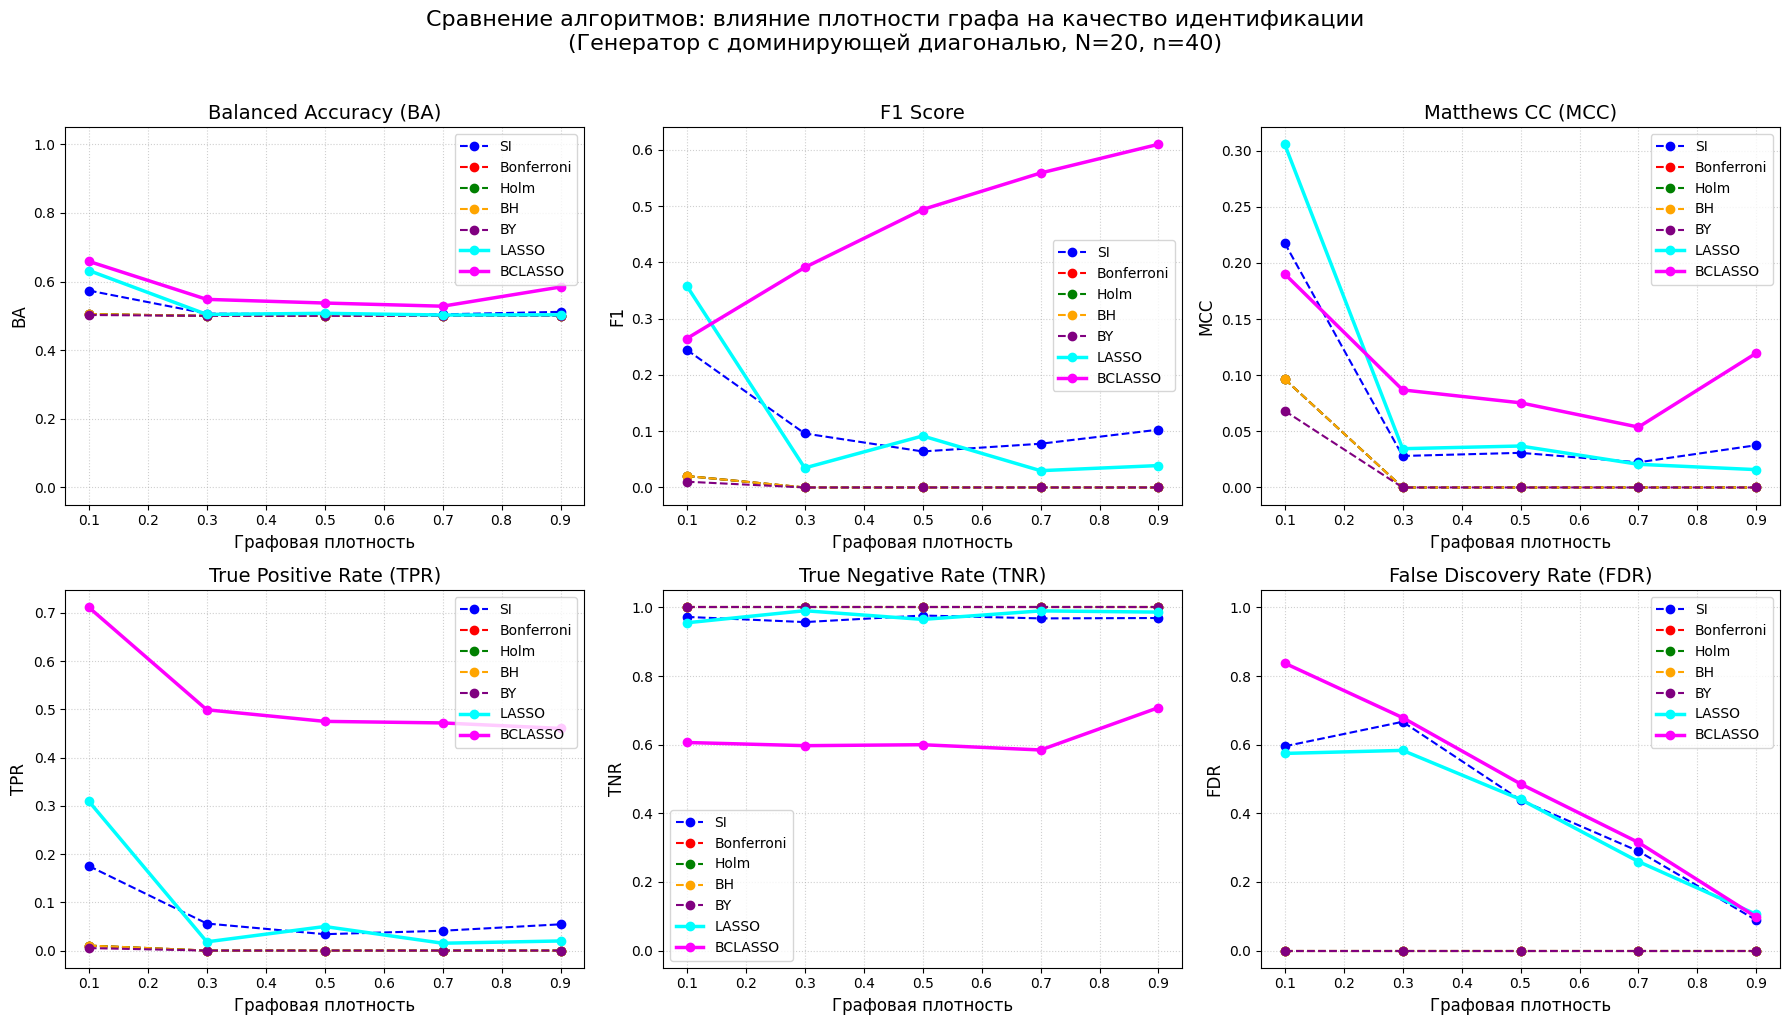

 Density          SI  Bonferroni        Holm          BH          BY       LASSO     BCLASSO
     0.1 0.245/0.218   0.020/0.097   0.020/0.097   0.020/0.097   0.010/0.068   0.358/0.306   0.265/0.190  
     0.3 0.096/0.028   0.000/0.000   0.000/0.000   0.000/0.000   0.000/0.000   0.035/0.035   0.391/0.087  
     0.5 0.064/0.031   0.000/0.000   0.000/0.000   0.000/0.000   0.000/0.000   0.092/0.037   0.494/0.075  
     0.7 0.078/0.022   0.000/0.000   0.000/0.000   0.000/0.000   0.000/0.000   0.030/0.021   0.559/0.054  
     0.9 0.103/0.038   0.000/0.000   0.000/0.000   0.000/0.000   0.000/0.000   0.039/0.016   0.610/0.120  


In [27]:
# ОСНОВНОЙ ЭКСПЕРИМЕНТ

N = 20            # d = 20
n_samples = 40    # n = 40
alphas = [0.1, 0.3, 0.5, 0.7, 0.9]
n_graphs = 10
n_obs = 1           # Количество выборок на модель (S_obs)

method_names = ['SI', 'Bonferroni', 'Holm', 'BH', 'BY', 'LASSO', 'BCLASSO']

# Структура для хранения результатов
results = {alpha: {method: {'TP': 0, 'TN': 0, 'FP': 0, 'FN': 0}
                   for method in method_names}
           for alpha in alphas}

print("Сравнение: SI, Bonferroni, Holm, BH, BY, LASSO, BCLASSO")

start_time = time.time()

for idx_d, density in enumerate(alphas):
    print(f"\n--- Плотность: {density:.1f} ({idx_d+1}/{len(alphas)}) ---")

    total_counts = {m: {'TP': 0, 'TN': 0, 'FP': 0, 'FN': 0} for m in method_names}

    for g in range(n_graphs):
        print(f"  Модель {g+1}/{n_graphs}", end="", flush=True)

        # Генерация истинной матрицы
        true_precision, true_adj = generate_precision_matrix_dominant_diagonal(N, density, seed=g*100+idx_d)

        # Вычисление ковариационной матрицы
        try:
            sigma = np.linalg.inv(true_precision)
        except np.linalg.LinAlgError:
            sigma = np.linalg.inv(true_precision + np.eye(N) * 0.01)

        # Сбор предсказаний по всем наблюдениям
        preds_over_obs = {m: [] for m in method_names}

        for obs in range(n_obs):
            # Генерация выборки
            X = np.random.multivariate_normal(np.zeros(N), sigma, n_samples)

            # --- Методы на основе p-values ---
            p_matrix = np.ones((N, N))
            for i in range(N):
                for j in range(i+1, N):
                    p_val = compute_partial_corr_pvalue(X, i, j)
                    p_matrix[i, j] = p_val
                    p_matrix[j, i] = p_val

            triu_idx = np.triu_indices_from(p_matrix, k=1)
            p_flat = p_matrix[triu_idx]

            pred_si = (p_flat < 0.05).astype(int)
            _, p_bonf, _, _ = multipletests(p_flat, alpha=0.05, method='bonferroni')
            _, p_holm, _, _ = multipletests(p_flat, alpha=0.05, method='holm')
            reject_bh, _, _, _ = multipletests(p_flat, alpha=0.05, method='fdr_bh')
            reject_by, _, _, _ = multipletests(p_flat, alpha=0.05, method='fdr_by')

            for name, pred in zip(['SI', 'Bonferroni', 'Holm', 'BH', 'BY'],
                                  [pred_si, (p_bonf < 0.05).astype(int),
                                   (p_holm < 0.05).astype(int),
                                   reject_bh.astype(int), reject_by.astype(int)]):
                pred_matrix = np.zeros((N, N))
                pred_matrix[triu_idx] = pred
                pred_matrix += pred_matrix.T
                preds_over_obs[name].append(pred_matrix)

            # --- Graphical LASSO ---
            try:
                gl_model = GraphicalLassoCV(cv=3, max_iter=100, assume_centered=True)
                gl_model.fit(X)
                pred_lasso = (np.abs(gl_model.precision_) > 1e-4).astype(int)
            except Exception:
                pred_lasso = np.zeros((N, N))
            np.fill_diagonal(pred_lasso, 0)
            preds_over_obs['LASSO'].append(pred_lasso)

            # --- BCLASSO ---
            pred_bclasso = run_bclasso(X, n_iter=3000, n_burn=1000)  # Уменьшено для скорости
            preds_over_obs['BCLASSO'].append(pred_bclasso)

        print(" — обработано")

        # Усреднение предсказаний по наблюдениям (мажоритарное голосование)
        for method in method_names:
            if not preds_over_obs[method]:
                continue

            stacked = np.array(preds_over_obs[method])
            final_pred = (np.mean(stacked, axis=0) > 0.5).astype(int)
            np.fill_diagonal(final_pred, 0)

            tp = np.sum((true_adj == 1) & (final_pred == 1)) // 2
            tn = np.sum((true_adj == 0) & (final_pred == 0)) // 2
            fp = np.sum((true_adj == 0) & (final_pred == 1)) // 2
            fn = np.sum((true_adj == 1) & (final_pred == 0)) // 2

            total_counts[method]['TP'] += tp
            total_counts[method]['TN'] += tn
            total_counts[method]['FP'] += fp
            total_counts[method]['FN'] += fn

    # Сохранение результатов для текущей плотности
    for method in method_names:
        results[density][method] = total_counts[method].copy()

print(f"\nЭксперимент завершен!")


# ============================================================
# 5. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================================

def compute_metrics(tp, tn, fp, fn):
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0

    f1 = 2 * (ppv * tpr) / (ppv + tpr) if (ppv + tpr) > 0 else 0
    ba = (tpr + tnr) / 2

    mcc_num = tp * tn - fp * fn
    mcc_den = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = mcc_num / mcc_den if mcc_den > 0 else 0

    fdr = 1 - ppv if (tp + fp) > 0 else 0
    for_metric = fp / (fp + tn) if (fp + tn) > 0 else 0

    return {'BA': ba, 'F1': f1, 'MCC': mcc, 'TPR': tpr, 'TNR': tnr, 'FDR': fdr, 'FOR': for_metric}

# Сбор метрик
metrics_data = {}
for d in alphas:
    metrics_data[d] = {}
    for method in method_names:
        metrics_data[d][method] = compute_metrics(
            results[d][method]['TP'],
            results[d][method]['TN'],
            results[d][method]['FP'],
            results[d][method]['FN']
        )

# Построение графиков
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_metrics = ['BA', 'F1', 'MCC', 'TPR', 'TNR', 'FDR']
titles = ['Balanced Accuracy (BA)', 'F1 Score', "Matthews CC (MCC)",
          'True Positive Rate (TPR)', 'True Negative Rate (TNR)',
          'False Discovery Rate (FDR)']

colors = {'SI': 'blue', 'Bonferroni': 'red', 'Holm': 'green',
          'BH': 'orange', 'BY': 'purple', 'LASSO': 'cyan',
          'BCLASSO': 'magenta'}
linewidths = {'LASSO': 2.5, 'BCLASSO': 2.5}
linestyles = {'LASSO': '-', 'BCLASSO': '-'}

for i, (metric, title) in enumerate(zip(plot_metrics, titles)):
    ax = axes[i // 3, i % 3]

    for method in method_names:
        values = [metrics_data[d][method][metric] for d in alphas]
        lw = linewidths.get(method, 1.5)
        ls = linestyles.get(method, '--')
        ax.plot(alphas, values, marker='o', label=method,
                color=colors.get(method, 'gray'),
                linewidth=lw, linestyle=ls)

    ax.set_xlabel('Графовая плотность', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='best')

    if metric in ['FDR', 'TNR', 'BA']:
        ax.set_ylim(-0.05, 1.05)

plt.suptitle('Сравнение алгоритмов: влияние плотности графа на качество идентификации\n'
             '(Генератор с доминирующей диагональю, N=20, n=40)',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print(f"{'Density':>8}", end="")
for method in method_names:
    print(f"{method:>12}", end="")
print()

for d in alphas:
    print(f"{d:>8.1f}", end="")
    for method in method_names:
        f1 = metrics_data[d][method]['F1']
        mcc = metrics_data[d][method]['MCC']
        print(f" {f1:.3f}/{mcc:.3f}  ", end="")
    print()

Сравнение: SI, Bonferroni, Holm, BH, BY, LASSO, BCLASSO

--- Плотность: 0.1 (1/5) ---
  Модель 1/10

/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:161: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  cand = phi_k + self.rng.multivariate_normal(np.zeros(d-1), V_k)
/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:181: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  aux_cand = w + self.rng.multivariate_normal(np.zeros(d-1), V_k)


 — обработано
  Модель 2/10

/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:161: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  cand = phi_k + self.rng.multivariate_normal(np.zeros(d-1), V_k)
/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:181: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  aux_cand = w + self.rng.multivariate_normal(np.zeros(d-1), V_k)


 — обработано
  Модель 3/10

...

 — обработано
  Модель 9/10

/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:161: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  cand = phi_k + self.rng.multivariate_normal(np.zeros(d-1), V_k)
/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:181: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  aux_cand = w + self.rng.multivariate_normal(np.zeros(d-1), V_k)


 — обработано
  Модель 10/10

/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:161: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  cand = phi_k + self.rng.multivariate_normal(np.zeros(d-1), V_k)
/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:181: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  aux_cand = w + self.rng.multivariate_normal(np.zeros(d-1), V_k)


 — обработано

Эксперимент завершен!


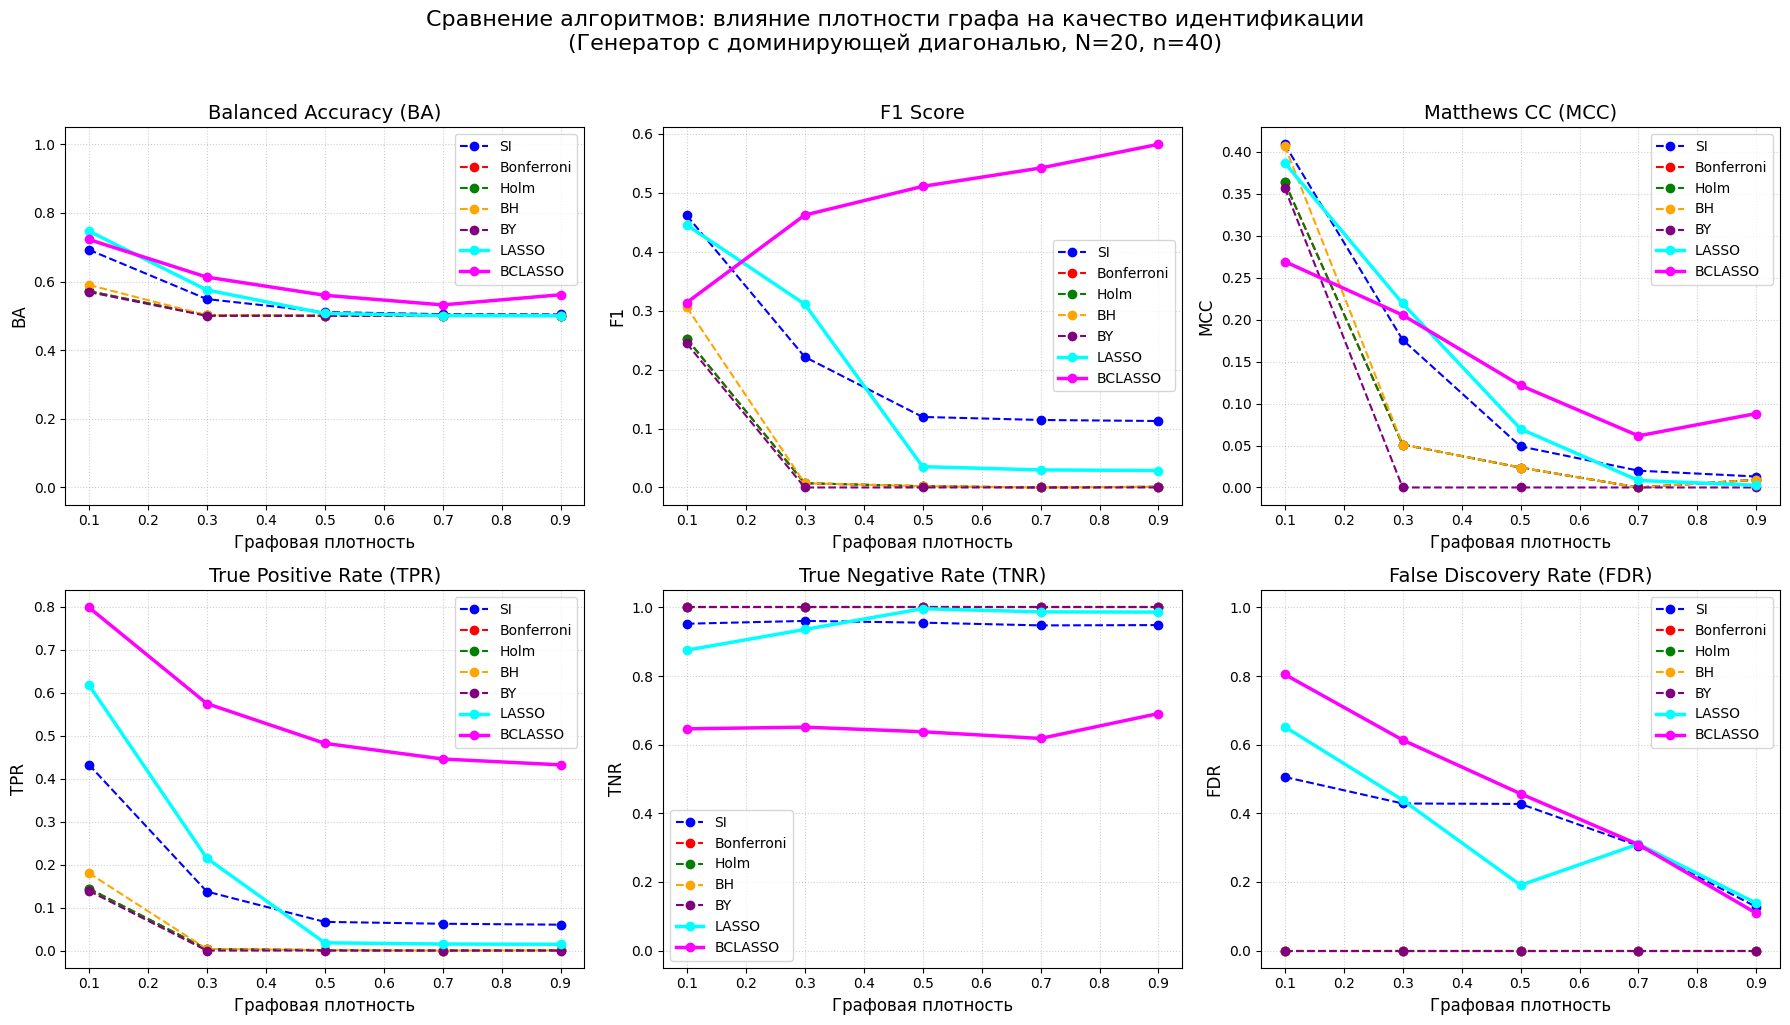

 Density          SI  Bonferroni        Holm          BH          BY       LASSO     BCLASSO
     0.1 0.462/0.409   0.252/0.364   0.252/0.364   0.306/0.407   0.244/0.357   0.445/0.387   0.314/0.269  
     0.3 0.222/0.176   0.007/0.051   0.007/0.051   0.007/0.051   0.000/0.000   0.311/0.219   0.462/0.205  
     0.5 0.120/0.049   0.002/0.024   0.002/0.024   0.002/0.024   0.000/0.000   0.035/0.070   0.511/0.122  
     0.7 0.115/0.020   0.000/0.000   0.000/0.000   0.000/0.000   0.000/0.000   0.030/0.008   0.542/0.062  
     0.9 0.113/0.013   0.001/0.009   0.001/0.009   0.001/0.009   0.000/0.000   0.029/0.003   0.582/0.088  


In [28]:
# ОСНОВНОЙ ЭКСПЕРИМЕНТ

N = 20             # d = 20
n_samples = 100    # n = 100
alphas = [0.1, 0.3, 0.5, 0.7, 0.9]
n_graphs = 10
n_obs = 1           # Количество выборок на модель (S_obs)

method_names = ['SI', 'Bonferroni', 'Holm', 'BH', 'BY', 'LASSO', 'BCLASSO']

# Структура для хранения результатов
results = {alpha: {method: {'TP': 0, 'TN': 0, 'FP': 0, 'FN': 0}
                   for method in method_names}
           for alpha in alphas}

print("Сравнение: SI, Bonferroni, Holm, BH, BY, LASSO, BCLASSO")

start_time = time.time()

for idx_d, density in enumerate(alphas):
    print(f"\n--- Плотность: {density:.1f} ({idx_d+1}/{len(alphas)}) ---")

    total_counts = {m: {'TP': 0, 'TN': 0, 'FP': 0, 'FN': 0} for m in method_names}

    for g in range(n_graphs):
        print(f"  Модель {g+1}/{n_graphs}", end="", flush=True)

        # Генерация истинной матрицы
        true_precision, true_adj = generate_precision_matrix_dominant_diagonal(N, density, seed=g*100+idx_d)

        # Вычисление ковариационной матрицы
        try:
            sigma = np.linalg.inv(true_precision)
        except np.linalg.LinAlgError:
            sigma = np.linalg.inv(true_precision + np.eye(N) * 0.01)

        # Сбор предсказаний по всем наблюдениям
        preds_over_obs = {m: [] for m in method_names}

        for obs in range(n_obs):
            # Генерация выборки
            X = np.random.multivariate_normal(np.zeros(N), sigma, n_samples)

            # --- Методы на основе p-values ---
            p_matrix = np.ones((N, N))
            for i in range(N):
                for j in range(i+1, N):
                    p_val = compute_partial_corr_pvalue(X, i, j)
                    p_matrix[i, j] = p_val
                    p_matrix[j, i] = p_val

            triu_idx = np.triu_indices_from(p_matrix, k=1)
            p_flat = p_matrix[triu_idx]

            pred_si = (p_flat < 0.05).astype(int)
            _, p_bonf, _, _ = multipletests(p_flat, alpha=0.05, method='bonferroni')
            _, p_holm, _, _ = multipletests(p_flat, alpha=0.05, method='holm')
            reject_bh, _, _, _ = multipletests(p_flat, alpha=0.05, method='fdr_bh')
            reject_by, _, _, _ = multipletests(p_flat, alpha=0.05, method='fdr_by')

            for name, pred in zip(['SI', 'Bonferroni', 'Holm', 'BH', 'BY'],
                                  [pred_si, (p_bonf < 0.05).astype(int),
                                   (p_holm < 0.05).astype(int),
                                   reject_bh.astype(int), reject_by.astype(int)]):
                pred_matrix = np.zeros((N, N))
                pred_matrix[triu_idx] = pred
                pred_matrix += pred_matrix.T
                preds_over_obs[name].append(pred_matrix)

            # --- Graphical LASSO ---
            try:
                gl_model = GraphicalLassoCV(cv=3, max_iter=100, assume_centered=True)
                gl_model.fit(X)
                pred_lasso = (np.abs(gl_model.precision_) > 1e-4).astype(int)
            except Exception:
                pred_lasso = np.zeros((N, N))
            np.fill_diagonal(pred_lasso, 0)
            preds_over_obs['LASSO'].append(pred_lasso)

            # --- BCLASSO ---
            pred_bclasso = run_bclasso(X, n_iter=3000, n_burn=1000)  # Уменьшено для скорости
            preds_over_obs['BCLASSO'].append(pred_bclasso)

        print(" — обработано")

        # Усреднение предсказаний по наблюдениям (мажоритарное голосование)
        for method in method_names:
            if not preds_over_obs[method]:
                continue

            stacked = np.array(preds_over_obs[method])
            final_pred = (np.mean(stacked, axis=0) > 0.5).astype(int)
            np.fill_diagonal(final_pred, 0)

            tp = np.sum((true_adj == 1) & (final_pred == 1)) // 2
            tn = np.sum((true_adj == 0) & (final_pred == 0)) // 2
            fp = np.sum((true_adj == 0) & (final_pred == 1)) // 2
            fn = np.sum((true_adj == 1) & (final_pred == 0)) // 2

            total_counts[method]['TP'] += tp
            total_counts[method]['TN'] += tn
            total_counts[method]['FP'] += fp
            total_counts[method]['FN'] += fn

    # Сохранение результатов для текущей плотности
    for method in method_names:
        results[density][method] = total_counts[method].copy()

print(f"\nЭксперимент завершен!")


# ============================================================
# 5. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================================

def compute_metrics(tp, tn, fp, fn):
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0

    f1 = 2 * (ppv * tpr) / (ppv + tpr) if (ppv + tpr) > 0 else 0
    ba = (tpr + tnr) / 2

    mcc_num = tp * tn - fp * fn
    mcc_den = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = mcc_num / mcc_den if mcc_den > 0 else 0

    fdr = 1 - ppv if (tp + fp) > 0 else 0
    for_metric = fp / (fp + tn) if (fp + tn) > 0 else 0

    return {'BA': ba, 'F1': f1, 'MCC': mcc, 'TPR': tpr, 'TNR': tnr, 'FDR': fdr, 'FOR': for_metric}

# Сбор метрик
metrics_data = {}
for d in alphas:
    metrics_data[d] = {}
    for method in method_names:
        metrics_data[d][method] = compute_metrics(
            results[d][method]['TP'],
            results[d][method]['TN'],
            results[d][method]['FP'],
            results[d][method]['FN']
        )

# Построение графиков
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_metrics = ['BA', 'F1', 'MCC', 'TPR', 'TNR', 'FDR']
titles = ['Balanced Accuracy (BA)', 'F1 Score', "Matthews CC (MCC)",
          'True Positive Rate (TPR)', 'True Negative Rate (TNR)',
          'False Discovery Rate (FDR)']

colors = {'SI': 'blue', 'Bonferroni': 'red', 'Holm': 'green',
          'BH': 'orange', 'BY': 'purple', 'LASSO': 'cyan',
          'BCLASSO': 'magenta'}
linewidths = {'LASSO': 2.5, 'BCLASSO': 2.5}
linestyles = {'LASSO': '-', 'BCLASSO': '-'}

for i, (metric, title) in enumerate(zip(plot_metrics, titles)):
    ax = axes[i // 3, i % 3]

    for method in method_names:
        values = [metrics_data[d][method][metric] for d in alphas]
        lw = linewidths.get(method, 1.5)
        ls = linestyles.get(method, '--')
        ax.plot(alphas, values, marker='o', label=method,
                color=colors.get(method, 'gray'),
                linewidth=lw, linestyle=ls)

    ax.set_xlabel('Графовая плотность', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='best')

    if metric in ['FDR', 'TNR', 'BA']:
        ax.set_ylim(-0.05, 1.05)

plt.suptitle('Сравнение алгоритмов: влияние плотности графа на качество идентификации\n'
             '(Генератор с доминирующей диагональю, N=20, n=40)',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print(f"{'Density':>8}", end="")
for method in method_names:
    print(f"{method:>12}", end="")
print()

for d in alphas:
    print(f"{d:>8.1f}", end="")
    for method in method_names:
        f1 = metrics_data[d][method]['F1']
        mcc = metrics_data[d][method]['MCC']
        print(f" {f1:.3f}/{mcc:.3f}  ", end="")
    print()

Сравнение: SI, Bonferroni, Holm, BH, BY, LASSO, BCLASSO

--- Плотность: 0.1 (1/5) ---
  Модель 1/10

/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:161: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  cand = phi_k + self.rng.multivariate_normal(np.zeros(d-1), V_k)
/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:181: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  aux_cand = w + self.rng.multivariate_normal(np.zeros(d-1), V_k)


 — обработано
  Модель 2/10

/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:161: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  cand = phi_k + self.rng.multivariate_normal(np.zeros(d-1), V_k)
/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:181: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  aux_cand = w + self.rng.multivariate_normal(np.zeros(d-1), V_k)


 — обработано
  Модель 3/10

...

 — обработано
  Модель 9/10

/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:161: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  cand = phi_k + self.rng.multivariate_normal(np.zeros(d-1), V_k)
/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:181: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  aux_cand = w + self.rng.multivariate_normal(np.zeros(d-1), V_k)


 — обработано
  Модель 10/10

/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:161: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  cand = phi_k + self.rng.multivariate_normal(np.zeros(d-1), V_k)
/var/folders/6f/vdt5hqyj37l4pzxp0b35ps6c0000gn/T/ipykernel_51602/3467065966.py:181: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  aux_cand = w + self.rng.multivariate_normal(np.zeros(d-1), V_k)


 — обработано

Эксперимент завершен!


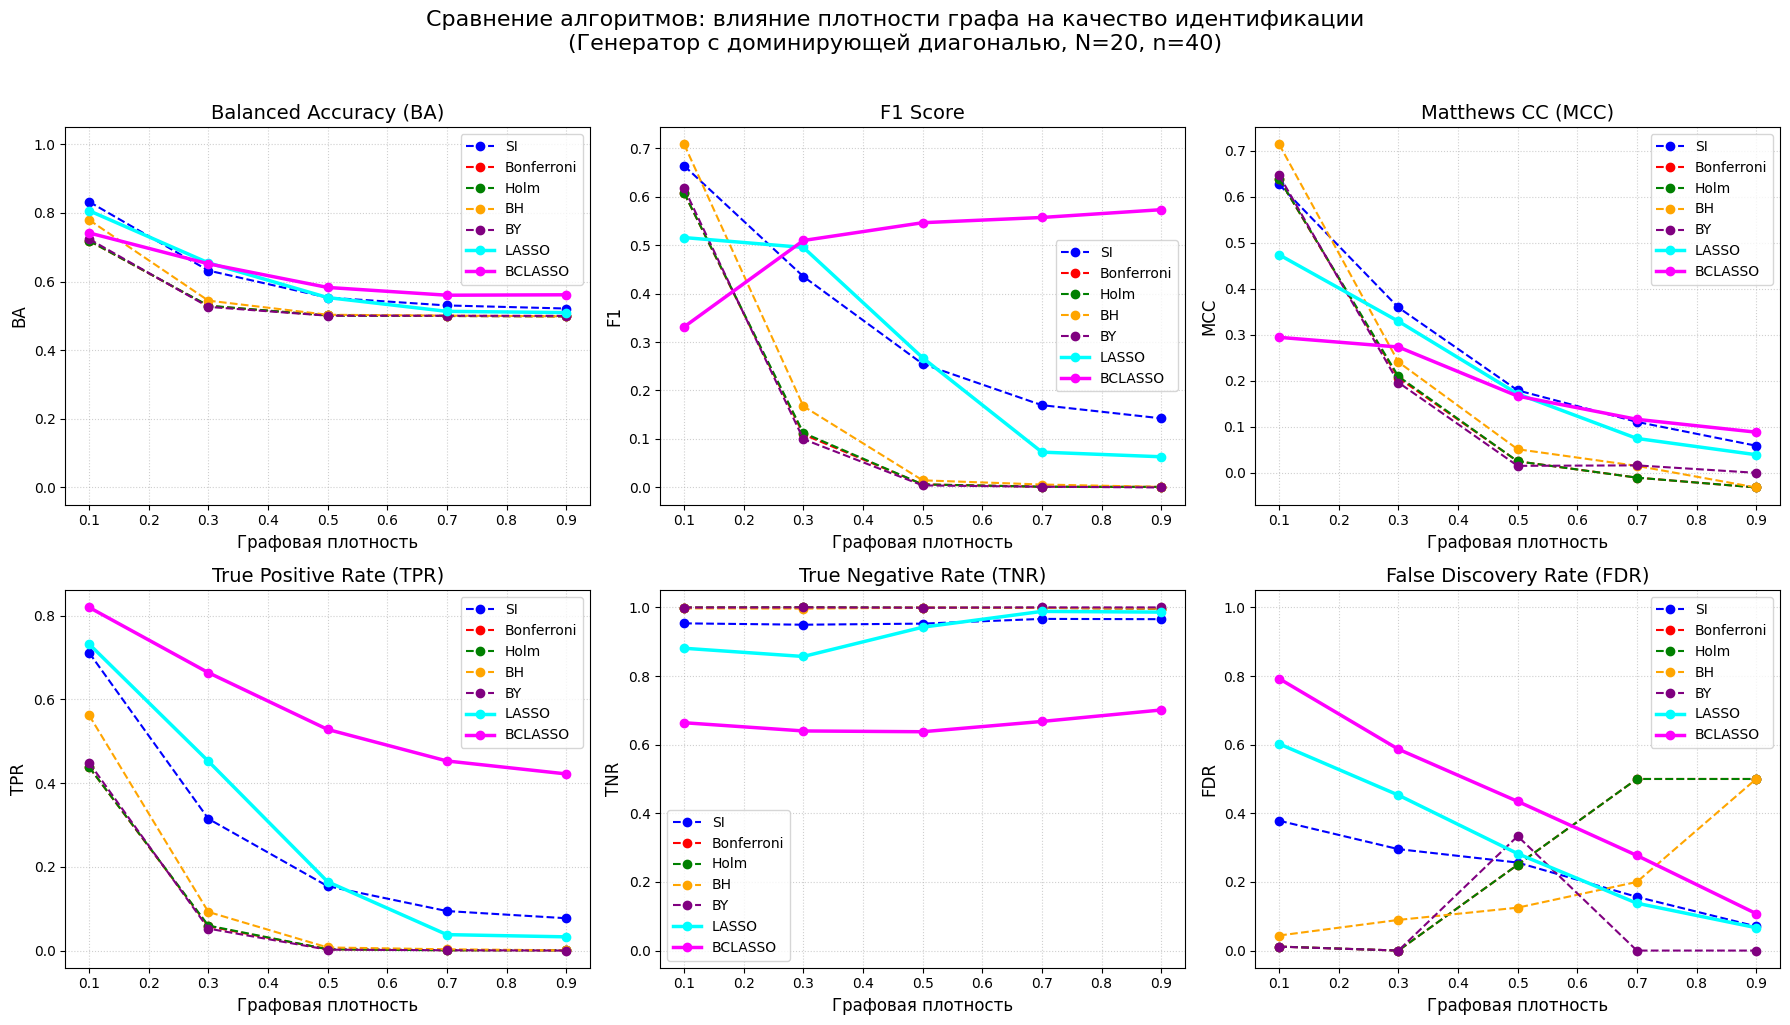

 Density          SI  Bonferroni        Holm          BH          BY       LASSO     BCLASSO
     0.1 0.663/0.626   0.607/0.638   0.607/0.638   0.708/0.714   0.617/0.646   0.515/0.474   0.331/0.294  
     0.3 0.435/0.359   0.109/0.206   0.113/0.210   0.167/0.241   0.100/0.196   0.495/0.329   0.509/0.273  
     0.5 0.255/0.179   0.006/0.025   0.006/0.025   0.015/0.051   0.004/0.015   0.267/0.172   0.546/0.167  
     0.7 0.170/0.111   0.002/-0.010   0.002/-0.010   0.006/0.015   0.002/0.016   0.073/0.075   0.557/0.116  
     0.9 0.143/0.059   0.001/-0.032   0.001/-0.032   0.001/-0.032   0.000/0.000   0.063/0.039   0.573/0.088  


In [30]:
# ОСНОВНОЙ ЭКСПЕРИМЕНТ

N = 20             # d = 20
n_samples = 300    # n = 100
alphas = [0.1, 0.3, 0.5, 0.7, 0.9]
n_graphs = 10
n_obs = 1           # Количество выборок на модель (S_obs)

method_names = ['SI', 'Bonferroni', 'Holm', 'BH', 'BY', 'LASSO', 'BCLASSO']

# Структура для хранения результатов
results = {alpha: {method: {'TP': 0, 'TN': 0, 'FP': 0, 'FN': 0}
                   for method in method_names}
           for alpha in alphas}

print("Сравнение: SI, Bonferroni, Holm, BH, BY, LASSO, BCLASSO")

start_time = time.time()

for idx_d, density in enumerate(alphas):
    print(f"\n--- Плотность: {density:.1f} ({idx_d+1}/{len(alphas)}) ---")

    total_counts = {m: {'TP': 0, 'TN': 0, 'FP': 0, 'FN': 0} for m in method_names}

    for g in range(n_graphs):
        print(f"  Модель {g+1}/{n_graphs}", end="", flush=True)

        # Генерация истинной матрицы
        true_precision, true_adj = generate_precision_matrix_dominant_diagonal(N, density, seed=g*100+idx_d)

        # Вычисление ковариационной матрицы
        try:
            sigma = np.linalg.inv(true_precision)
        except np.linalg.LinAlgError:
            sigma = np.linalg.inv(true_precision + np.eye(N) * 0.01)

        # Сбор предсказаний по всем наблюдениям
        preds_over_obs = {m: [] for m in method_names}

        for obs in range(n_obs):
            # Генерация выборки
            X = np.random.multivariate_normal(np.zeros(N), sigma, n_samples)

            # --- Методы на основе p-values ---
            p_matrix = np.ones((N, N))
            for i in range(N):
                for j in range(i+1, N):
                    p_val = compute_partial_corr_pvalue(X, i, j)
                    p_matrix[i, j] = p_val
                    p_matrix[j, i] = p_val

            triu_idx = np.triu_indices_from(p_matrix, k=1)
            p_flat = p_matrix[triu_idx]

            pred_si = (p_flat < 0.05).astype(int)
            _, p_bonf, _, _ = multipletests(p_flat, alpha=0.05, method='bonferroni')
            _, p_holm, _, _ = multipletests(p_flat, alpha=0.05, method='holm')
            reject_bh, _, _, _ = multipletests(p_flat, alpha=0.05, method='fdr_bh')
            reject_by, _, _, _ = multipletests(p_flat, alpha=0.05, method='fdr_by')

            for name, pred in zip(['SI', 'Bonferroni', 'Holm', 'BH', 'BY'],
                                  [pred_si, (p_bonf < 0.05).astype(int),
                                   (p_holm < 0.05).astype(int),
                                   reject_bh.astype(int), reject_by.astype(int)]):
                pred_matrix = np.zeros((N, N))
                pred_matrix[triu_idx] = pred
                pred_matrix += pred_matrix.T
                preds_over_obs[name].append(pred_matrix)

            # --- Graphical LASSO ---
            try:
                gl_model = GraphicalLassoCV(cv=3, max_iter=100, assume_centered=True)
                gl_model.fit(X)
                pred_lasso = (np.abs(gl_model.precision_) > 1e-4).astype(int)
            except Exception:
                pred_lasso = np.zeros((N, N))
            np.fill_diagonal(pred_lasso, 0)
            preds_over_obs['LASSO'].append(pred_lasso)

            # --- BCLASSO ---
            pred_bclasso = run_bclasso(X, n_iter=3000, n_burn=1000)  # Уменьшено для скорости
            preds_over_obs['BCLASSO'].append(pred_bclasso)

        print(" — обработано")

        # Усреднение предсказаний по наблюдениям (мажоритарное голосование)
        for method in method_names:
            if not preds_over_obs[method]:
                continue

            stacked = np.array(preds_over_obs[method])
            final_pred = (np.mean(stacked, axis=0) > 0.5).astype(int)
            np.fill_diagonal(final_pred, 0)

            tp = np.sum((true_adj == 1) & (final_pred == 1)) // 2
            tn = np.sum((true_adj == 0) & (final_pred == 0)) // 2
            fp = np.sum((true_adj == 0) & (final_pred == 1)) // 2
            fn = np.sum((true_adj == 1) & (final_pred == 0)) // 2

            total_counts[method]['TP'] += tp
            total_counts[method]['TN'] += tn
            total_counts[method]['FP'] += fp
            total_counts[method]['FN'] += fn

    # Сохранение результатов для текущей плотности
    for method in method_names:
        results[density][method] = total_counts[method].copy()

print(f"\nЭксперимент завершен!")


# ============================================================
# 5. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================================

def compute_metrics(tp, tn, fp, fn):
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0

    f1 = 2 * (ppv * tpr) / (ppv + tpr) if (ppv + tpr) > 0 else 0
    ba = (tpr + tnr) / 2

    mcc_num = tp * tn - fp * fn
    mcc_den = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = mcc_num / mcc_den if mcc_den > 0 else 0

    fdr = 1 - ppv if (tp + fp) > 0 else 0
    for_metric = fp / (fp + tn) if (fp + tn) > 0 else 0

    return {'BA': ba, 'F1': f1, 'MCC': mcc, 'TPR': tpr, 'TNR': tnr, 'FDR': fdr, 'FOR': for_metric}

# Сбор метрик
metrics_data = {}
for d in alphas:
    metrics_data[d] = {}
    for method in method_names:
        metrics_data[d][method] = compute_metrics(
            results[d][method]['TP'],
            results[d][method]['TN'],
            results[d][method]['FP'],
            results[d][method]['FN']
        )

# Построение графиков
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_metrics = ['BA', 'F1', 'MCC', 'TPR', 'TNR', 'FDR']
titles = ['Balanced Accuracy (BA)', 'F1 Score', "Matthews CC (MCC)",
          'True Positive Rate (TPR)', 'True Negative Rate (TNR)',
          'False Discovery Rate (FDR)']

colors = {'SI': 'blue', 'Bonferroni': 'red', 'Holm': 'green',
          'BH': 'orange', 'BY': 'purple', 'LASSO': 'cyan',
          'BCLASSO': 'magenta'}
linewidths = {'LASSO': 2.5, 'BCLASSO': 2.5}
linestyles = {'LASSO': '-', 'BCLASSO': '-'}

for i, (metric, title) in enumerate(zip(plot_metrics, titles)):
    ax = axes[i // 3, i % 3]

    for method in method_names:
        values = [metrics_data[d][method][metric] for d in alphas]
        lw = linewidths.get(method, 1.5)
        ls = linestyles.get(method, '--')
        ax.plot(alphas, values, marker='o', label=method,
                color=colors.get(method, 'gray'),
                linewidth=lw, linestyle=ls)

    ax.set_xlabel('Графовая плотность', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='best')

    if metric in ['FDR', 'TNR', 'BA']:
        ax.set_ylim(-0.05, 1.05)

plt.suptitle('Сравнение алгоритмов: влияние плотности графа на качество идентификации\n'
             '(Генератор с доминирующей диагональю, N=20, n=40)',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print(f"{'Density':>8}", end="")
for method in method_names:
    print(f"{method:>12}", end="")
print()

for d in alphas:
    print(f"{d:>8.1f}", end="")
    for method in method_names:
        f1 = metrics_data[d][method]['F1']
        mcc = metrics_data[d][method]['MCC']
        print(f" {f1:.3f}/{mcc:.3f}  ", end="")
    print()